In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import numpy as np
import os
import quantities as pq

import epych
from epych.statistics import alignment, spectrum

[striatum:190220] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/2516123648/shared_mem_cuda_pool.striatum could be created.
[striatum:190220] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
ADAPTED_ONSET = pq.Quantity(-1.0) * pq.second
ADAPTED_OFFSET = pq.Quantity(-0.5) * pq.second
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
EVENTS = {
    "Adapted": (ADAPTED_ONSET.magnitude, 'lightgreen'),
    "Adapted Offset": (ADAPTED_OFFSET.magnitude, 'red'),
    "Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
    "Offset": (ODDBALL_OFFSET.magnitude, 'red'),
}

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
CONDITION_TITLES = {
    "lonaive": "Habituation",
    "go_gloexp": "Global Oddball",
    "go_seqctl": "AAAA Control",
    "lo_gloexp": "Local Oddball",
    "lo_rndctl": "AAAB Random",
    "igo_seqctl": "BBBB Control"
}

In [8]:
area_titles = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
def stattitle(name, stat):
    if name in area_titles:
        return area_titles[name]
    return name
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [9]:
def line_plot_callback(self, ax):
    for (event, (time, color)) in EVENTS.items():
        time = pq.Quantity(time, pq.second).rescale("ms")
        ax.vlines(time, *ax.get_ybound(), colors=color,
                  linestyles='dashed', label=event)
        ax.annotate(event, (time.magnitude, ax.get_ybound()[1] - 1),
                    color=color)
    ax.set_ylabel("Potential (uV)")

In [10]:
def condition_stattitle(cond, name, stat):
    return stattitle(name, stat) + (" (%s)" % CONDITION_TITLES[cond])

In [11]:
def samplings():
    for cond in CONDITIONS:
        logging.info("Loading LFPs for condition %s" % cond)
        sampling = epych.recording.Sampling.unpickle("/mnt/data/000253/grandcat_%s" % cond)
        logging.info("Loaded LFPs for condition %s, baseline from (%f, %f)" % (cond, -3.50, -3.))
        yield sampling.smap(lambda sig: sig.downsample(4).baseline_correct(-3.50, -3.))
        del sampling

INFO:root:Loading LFPs for condition lonaive
INFO:root:Loaded LFPs for condition lonaive, baseline from (-3.500000, -3.000000)


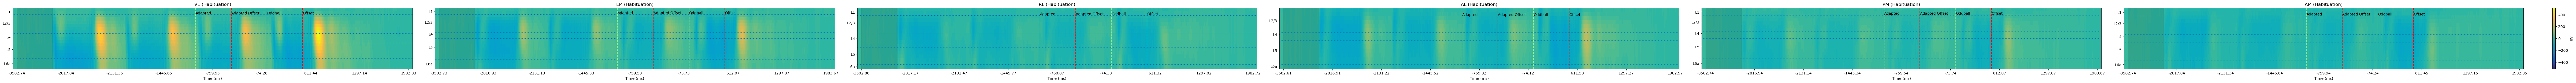

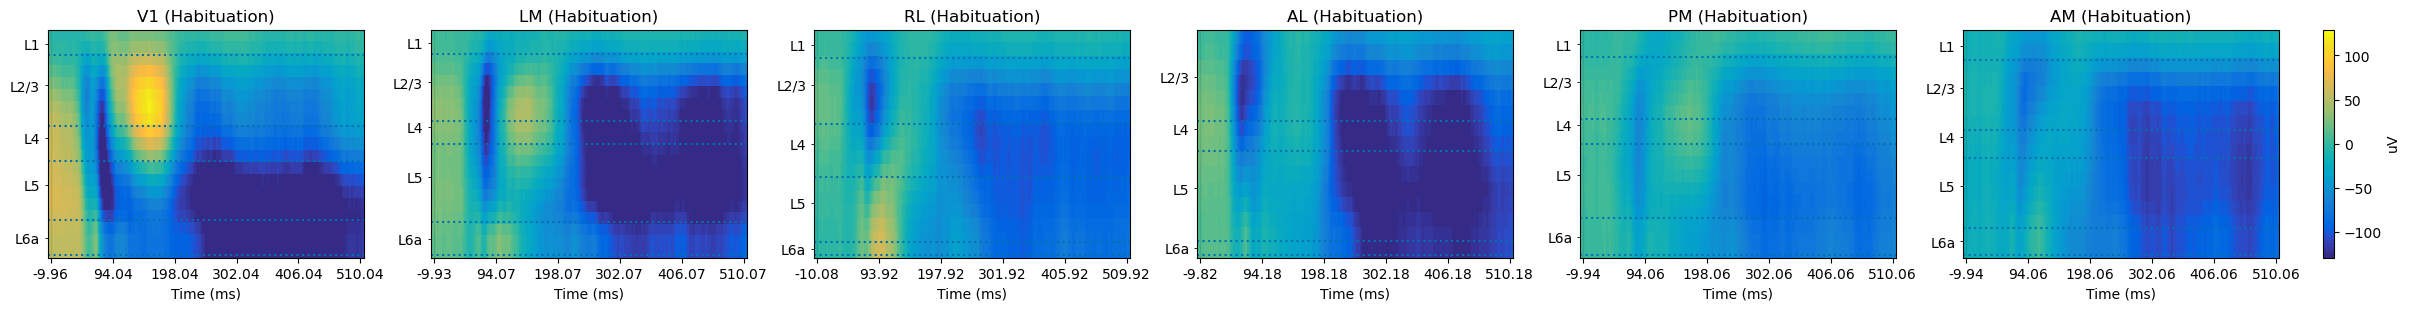

INFO:root:Loading LFPs for condition go_gloexp
INFO:root:Loaded LFPs for condition go_gloexp, baseline from (-3.500000, -3.000000)


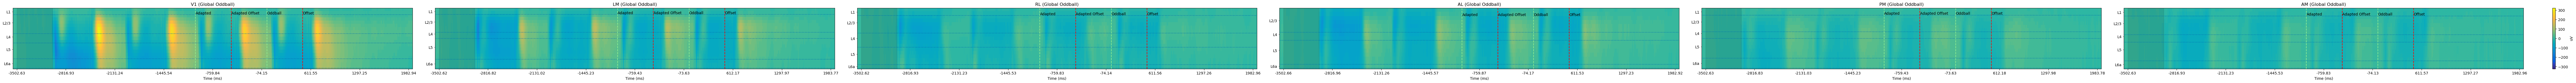

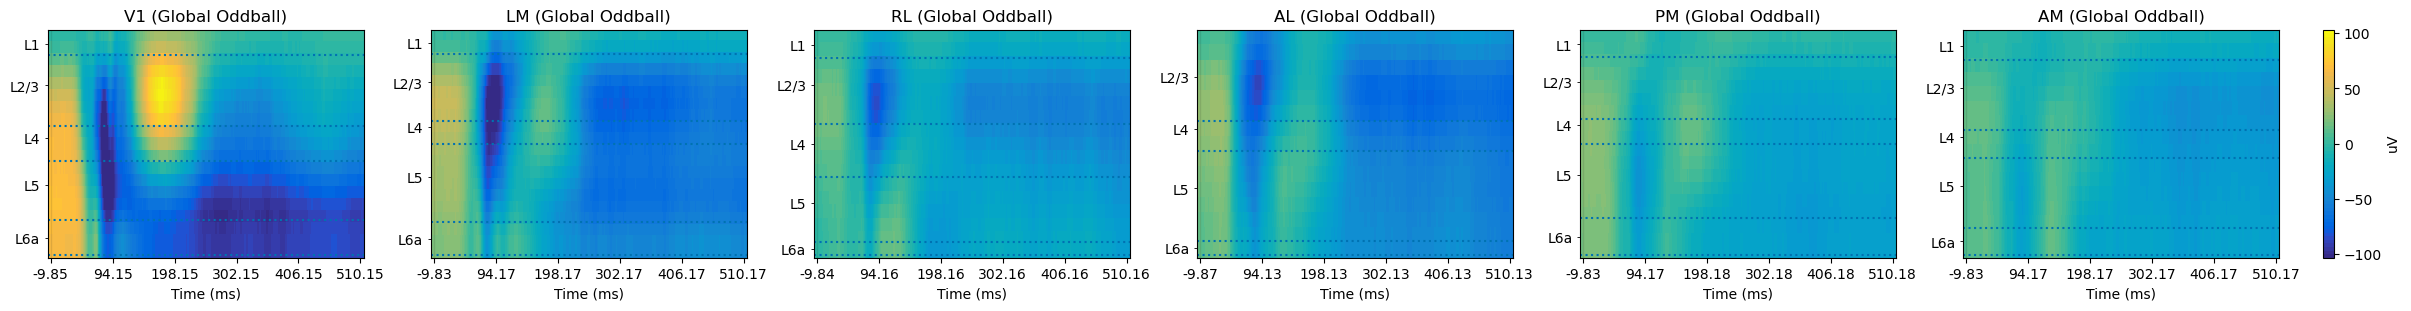

INFO:root:Loading LFPs for condition go_seqctl
INFO:root:Loaded LFPs for condition go_seqctl, baseline from (-3.500000, -3.000000)


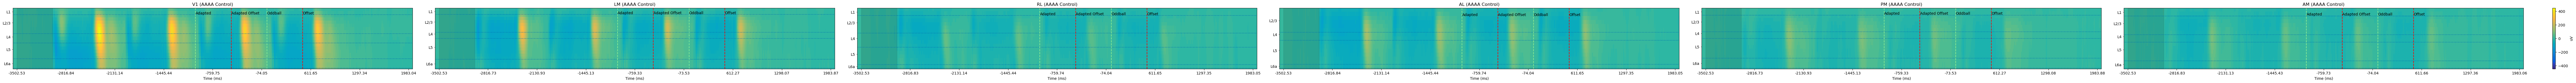

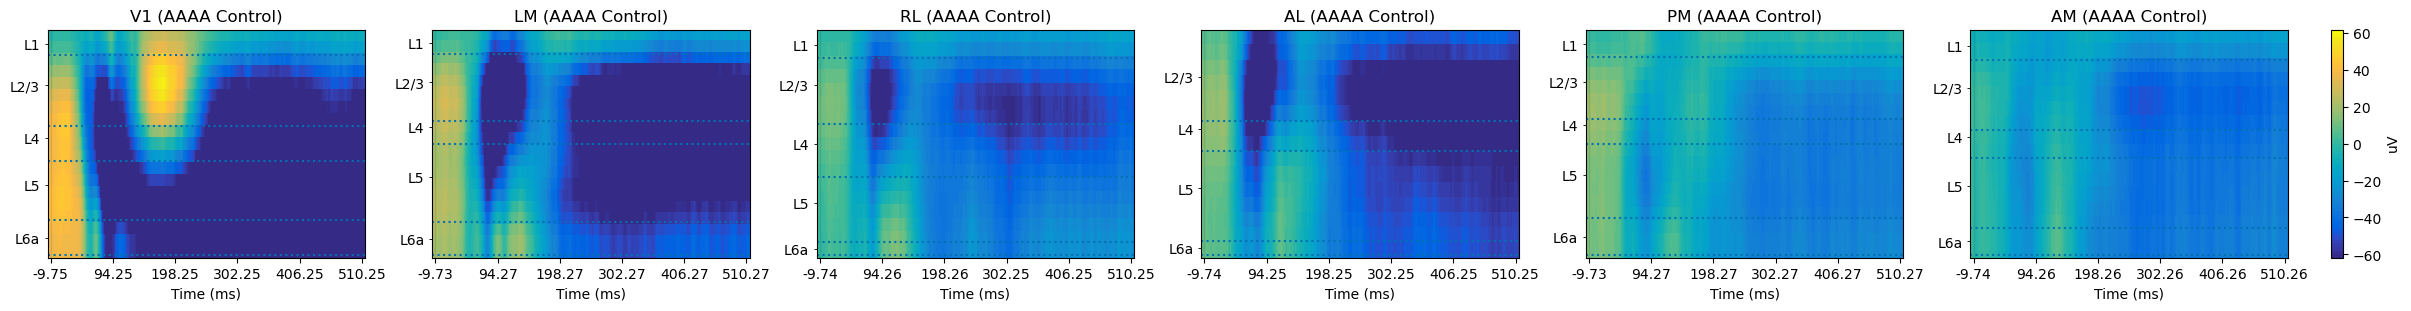

INFO:root:Loading LFPs for condition lo_gloexp
INFO:root:Loaded LFPs for condition lo_gloexp, baseline from (-3.500000, -3.000000)


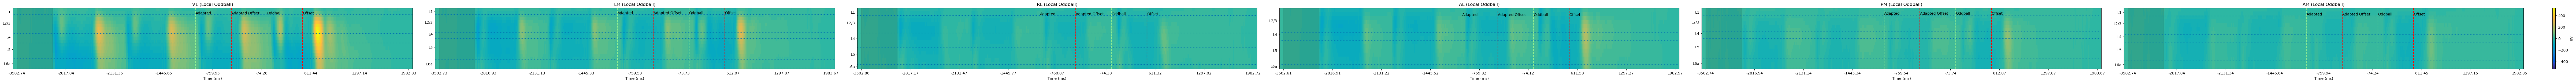

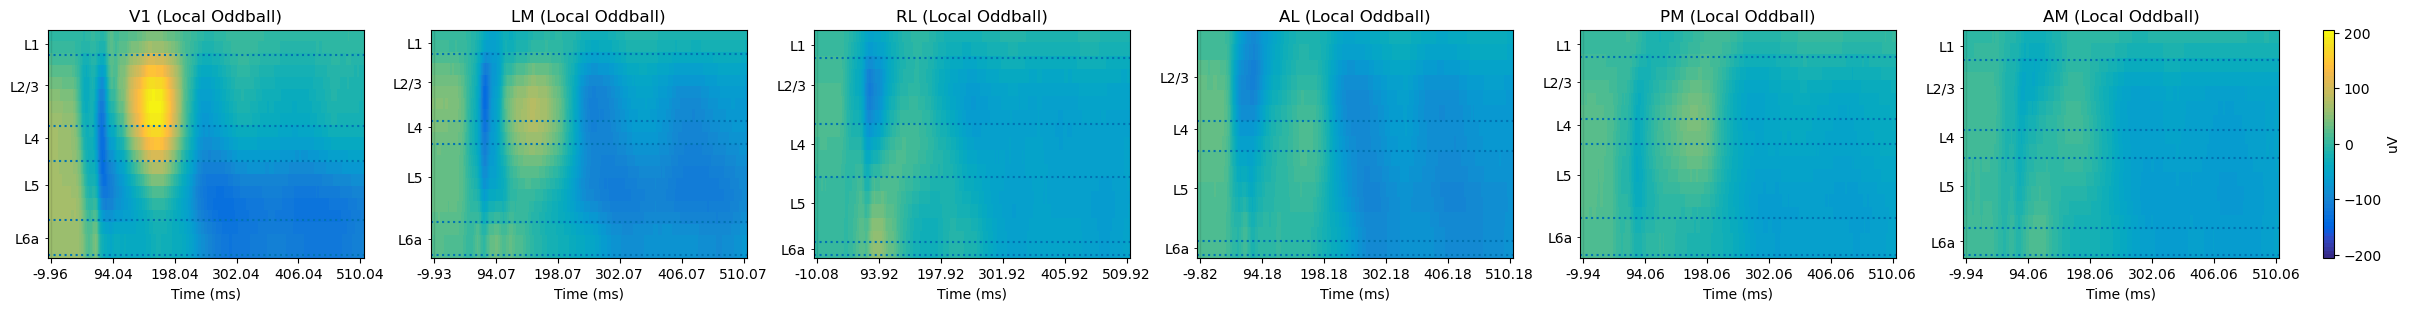

INFO:root:Loading LFPs for condition lo_rndctl
INFO:root:Loaded LFPs for condition lo_rndctl, baseline from (-3.500000, -3.000000)


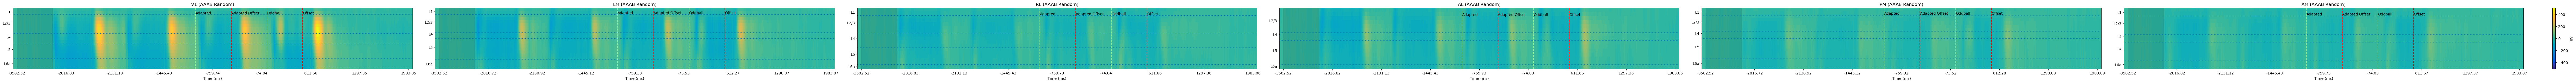

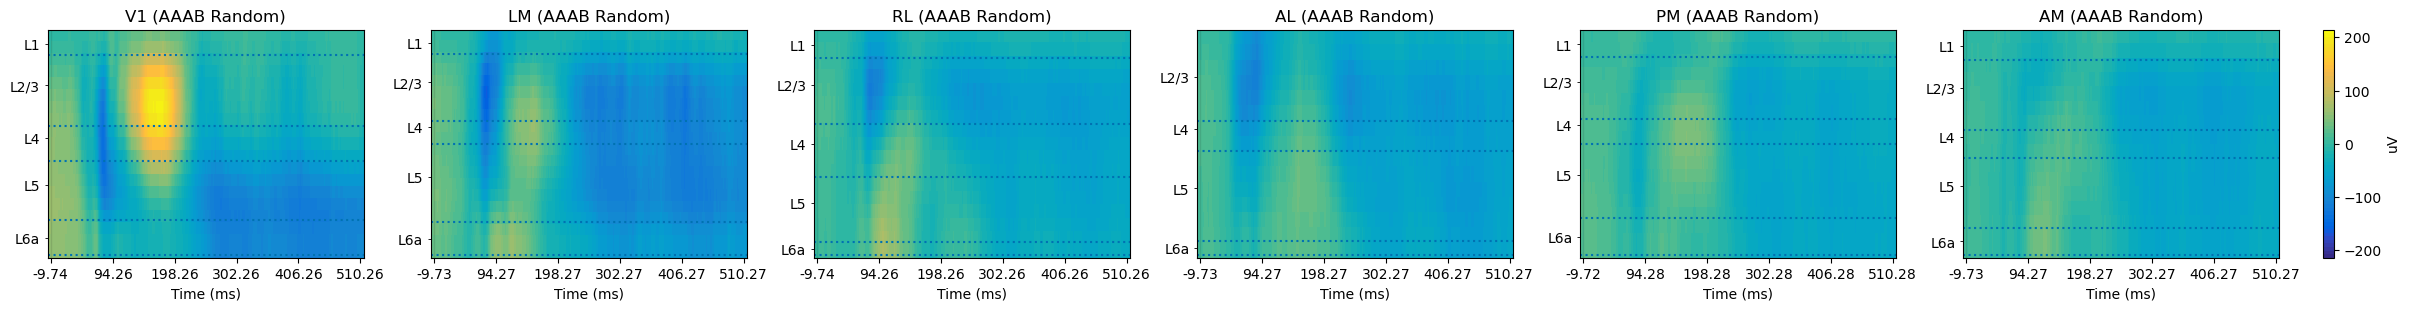

INFO:root:Loading LFPs for condition igo_seqctl
INFO:root:Loaded LFPs for condition igo_seqctl, baseline from (-3.500000, -3.000000)


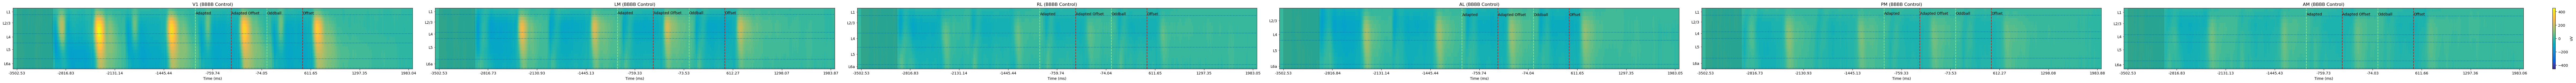

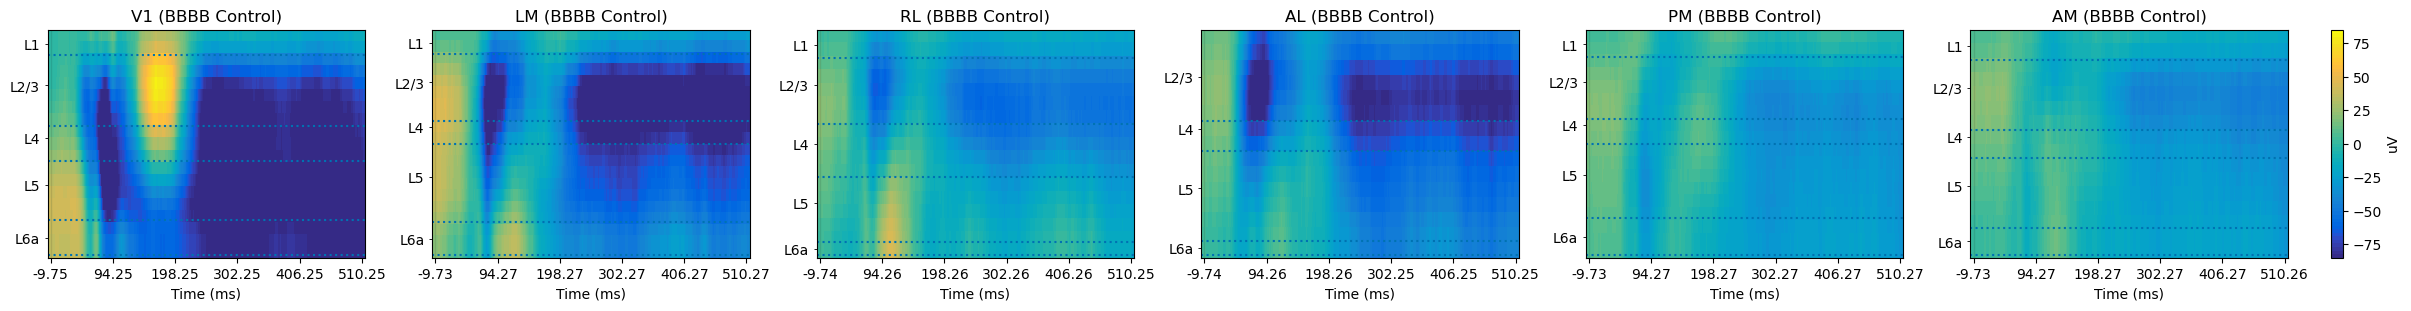

In [12]:
for cond, sampling in zip(CONDITIONS, samplings()):
    os.makedirs("%s_lfps/" % cond, exist_ok=True)
    cond_stattitle = functools.partial(condition_stattitle, cond)
    evoked = sampling.erp().smap(lambda sig: sig.fmap(lambda data: data.rescale("uV")))
    evoked.plot(figure="%s_lfps/erp.png" % cond, signals=anatomical_areas, sigtitle=cond_stattitle, baseline=(-3.50, -3.), decimals=4,
                width_per_signal=16 * pq.point, **EVENTS)

    oddballs = evoked.smap(lambda sig: sig[ODDBALL_ONSET.magnitude - 0.010:ODDBALL_OFFSET.magnitude + 0.010])
    oddballs.plot(figure="%s_lfps/oddball_erp.png" % cond, signals=anatomical_areas, sigtitle=cond_stattitle, baseline=(-3.50, -3.), decimals=4)
    for area in anatomical_areas:
        oddballs.signals[area].plot(title=cond_stattitle(area, oddballs.signals[area]), filename="%s_lfps/%s_oddball.svg" % (cond, area))
        oddballs.signals[area].select_channels([ch == oddballs.signals[area].num_channels // 2 for ch in range(oddballs.signals[area].num_channels)]).line_plot(
            title=cond_stattitle(area, oddballs.signals[area]), filename="%s_lfps/%s_oddball_L4.svg" % (cond, area),
            legend=False, callback=line_plot_callback
        )

    del oddballs
    del evoked